In [224]:
import os
import glob
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# imputation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", 100)

In [225]:
file_list = glob.glob(r"C:\Users\zahir\CRMLSSold*.csv")
dataframes = [pd.read_csv(file) for file in file_list]
df = pd.concat(dataframes, ignore_index=True)

C:\Users\zahir\AppData\Local\Temp\ipykernel_23656\405482455.py:2: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_23656\405482455.py:2: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_23656\405482455.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_23656\405482455.py:2: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]


In [226]:
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]

---
# 1. Initial Data Cleaning

- BEFORE FILTERING -
Total Observations: 399157
Minimum Close Price: $0.00
Maximum Close Price: $989,500,000.00


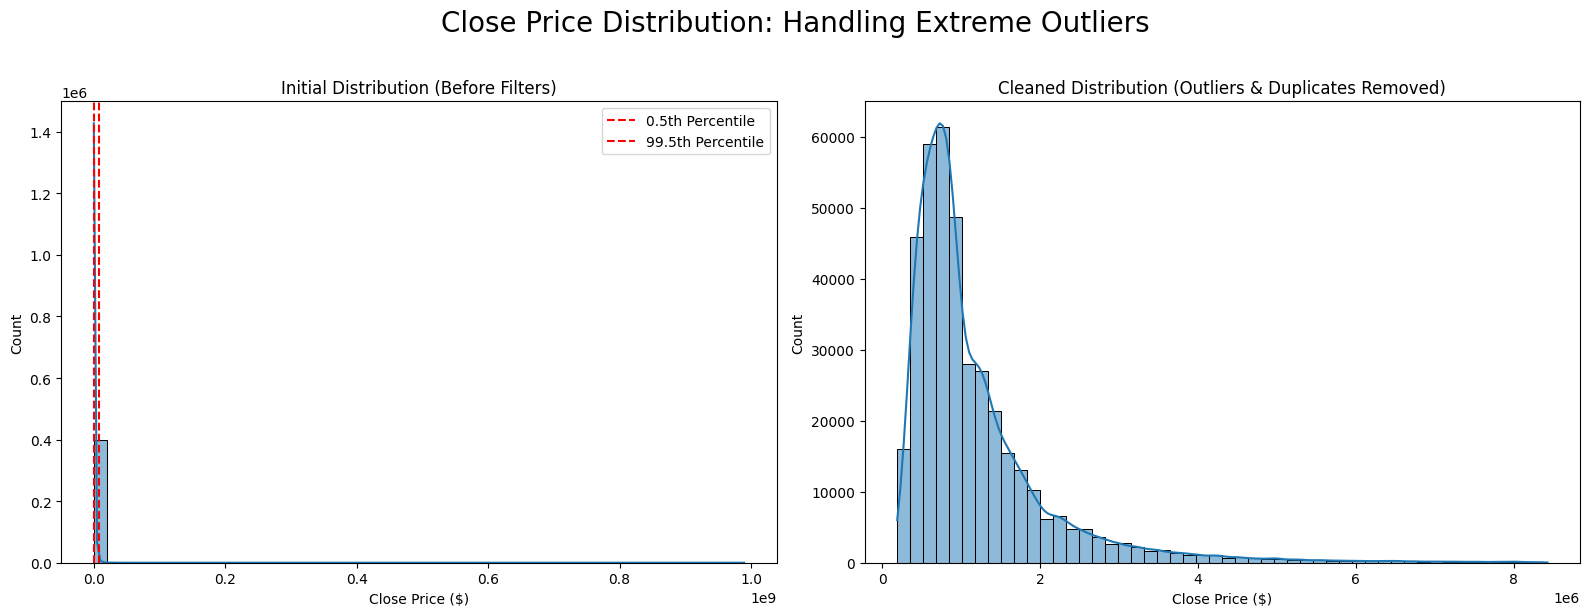

- AFTER FILTERING -
Dropped 4021 observations, 395136 remain.
New Minimum Close Price: $189,000.00
New Maximum Close Price: $8,430,000.00


In [227]:
initial_length = len(df)
lower_quantile = df["ClosePrice"].quantile(0.005)
upper_quantile = df["ClosePrice"].quantile(0.995)


print("- BEFORE FILTERING -")
print(f"Total Observations: {initial_length}")
print(f"Minimum Close Price: ${df['ClosePrice'].min():,.2f}")
print(f"Maximum Close Price: ${df['ClosePrice'].max():,.2f}")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
fig.suptitle('Close Price Distribution: Handling Extreme Outliers', fontsize=20, y=1.02)

# plot before filtering
sns.histplot(df['ClosePrice'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Initial Distribution (Before Filters)')
axes[0].set_xlabel('Close Price ($)')
axes[0].axvline(x=lower_quantile, color='red', linestyle='--', label='0.5th Percentile')
axes[0].axvline(x=upper_quantile, color='red', linestyle='--', label='99.5th Percentile')
axes[0].legend()

# filter
df = df[df["ClosePrice"].between(lower_quantile, upper_quantile)]
df = df.drop_duplicates(subset=['ListingKey', 'ClosePrice', 'CloseDate'], keep='first')

# plot after filtering
sns.histplot(df['ClosePrice'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Cleaned Distribution (Outliers & Duplicates Removed)')
axes[1].set_xlabel('Close Price ($)')

plt.tight_layout()
plt.show()

print("- AFTER FILTERING -")
print(f"Dropped {initial_length - len(df)} observations, {len(df)} remain.")
print(f"New Minimum Close Price: ${df['ClosePrice'].min():,.2f}")
print(f"New Maximum Close Price: ${df['ClosePrice'].max():,.2f}")

- BEFORE FILTERING -
GarageSpaces unique: [  2.     1.     3.      nan   0.     4.     5.     8.     7.    30.
   1.5    2.5    6.     9.    12.    11.    23.    10.    20.    50.
 200.    14.     4.5   15.    22.     3.5   31.   500.   400.    18.
  25.   600.     2.25  33.   300.     1.75  17.     5.5   13.    16.
  82.    48.    42.    19.    21.    24.    40.    32.    28.    35.  ] 

Bathrooms unique:  [  4.   3.   2.   1.   5.   8.   6.   9.   7.  12.  10.   0.  nan  11.
  13.  20.  15.  14. 175.  16. 153.  21.  22.  25.  45.  31.  17.  35.
  18.] 

Bedrooms unique:   [ 4.  3.  2.  6.  5.  1.  7.  9. 13.  8.  0. 15. 10. 12. 11. 22. 14. 34.
 31. 45. 17. 16.] 

ParkingTotal stats:
count    387610.000000
mean          3.042420
std          39.132879
min        -143.000000
25%           2.000000
50%           2.000000
75%           3.000000
max       15720.000000
Name: ParkingTotal, dtype: float64 



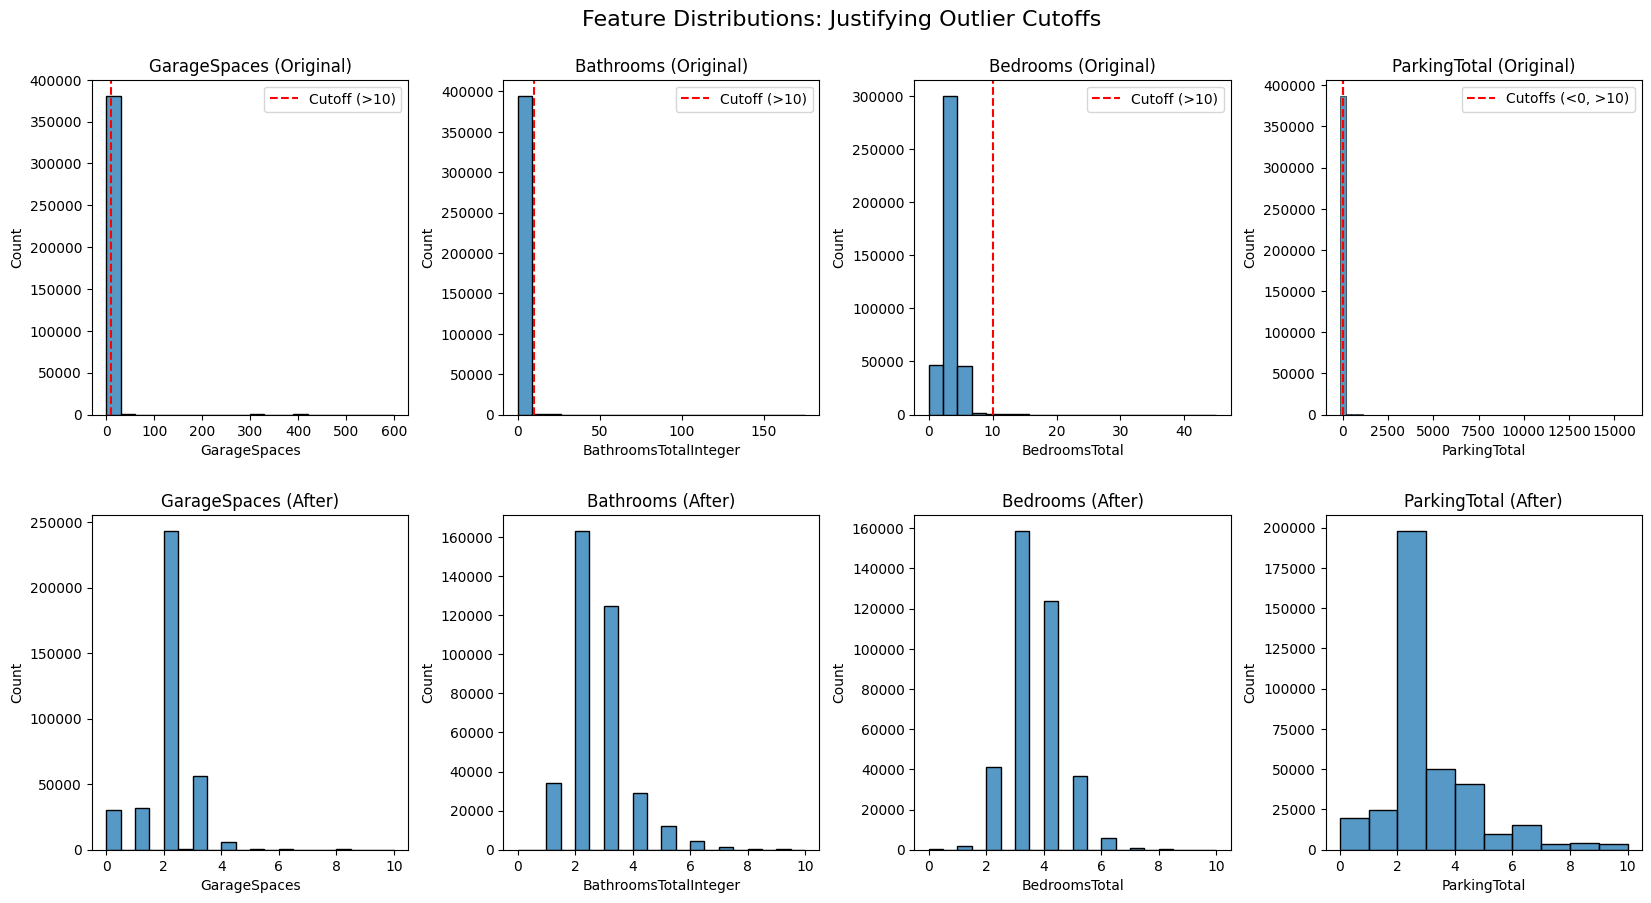

--- AFTER FILTERING ---
GarageSpaces unique: [ 2.    1.    3.    0.    4.    8.    7.    1.5   5.    2.5   6.    9.
 10.    4.5   3.5   2.25  1.75  5.5 ] 

Bathrooms unique:  [ 4.  3.  2.  1.  5.  8.  6.  7. 10.  0.  9.] 

Bedrooms unique:   [ 4.  3.  2.  6.  5.  1.  7.  9.  0.  8. 10.] 

ParkingTotal stats:
count    369587.000000
mean          2.614972
std           1.592346
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: ParkingTotal, dtype: float64 



In [228]:
print("- BEFORE FILTERING -")
print(f"GarageSpaces unique: {df['GarageSpaces'].unique()} \n")
print(f"Bathrooms unique:  {df['BathroomsTotalInteger'].unique()} \n")
print(f"Bedrooms unique:   {df['BedroomsTotal'].unique()} \n")
print(f"ParkingTotal stats:\n{df['ParkingTotal'].describe()} \n")


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.3)
fig.suptitle('Feature Distributions: Justifying Outlier Cutoffs', fontsize=16, y=0.95)

# plot before filtering
sns.histplot(df["GarageSpaces"], bins=20, ax=axes[0, 0]).set_title("GarageSpaces (Original)")
axes[0, 0].axvline(x=10, color='red', linestyle='--', label='Cutoff (>10)')
axes[0, 0].legend()

sns.histplot(df["BathroomsTotalInteger"], bins=20, ax=axes[0, 1]).set_title("Bathrooms (Original)")
axes[0, 1].axvline(x=10, color='red', linestyle='--', label='Cutoff (>10)')
axes[0, 1].legend()

sns.histplot(df["BedroomsTotal"], bins=20, ax=axes[0, 2]).set_title("Bedrooms (Original)")
axes[0, 2].axvline(x=10, color='red', linestyle='--', label='Cutoff (>10)')
axes[0, 2].legend()

sns.histplot(df["ParkingTotal"], bins=50, ax=axes[0, 3]).set_title("ParkingTotal (Original)")
axes[0, 3].axvline(x=0, color='red', linestyle='--')
axes[0, 3].axvline(x=10, color='red', linestyle='--', label='Cutoffs (<0, >10)')
axes[0, 3].legend()

# filter
df = df[df['GarageSpaces'] <= 10]
df = df[df['BathroomsTotalInteger'] <= 10]
df = df[df['BedroomsTotal'] <= 10]
df = df[(df['ParkingTotal'] >= 0) & (df['ParkingTotal'] <= 10)]

# plot after filtering
sns.histplot(df["GarageSpaces"], bins=20, ax=axes[1, 0]).set_title("GarageSpaces (After)")
sns.histplot(df["BathroomsTotalInteger"], bins=20, ax=axes[1, 1]).set_title("Bathrooms (After)")
sns.histplot(df["BedroomsTotal"], bins=20, ax=axes[1, 2]).set_title("Bedrooms (After)")
sns.histplot(df["ParkingTotal"], bins=10, ax=axes[1, 3]).set_title("ParkingTotal (After)")

plt.show()

print("--- AFTER FILTERING ---")
print(f"GarageSpaces unique: {df['GarageSpaces'].unique()} \n")
print(f"Bathrooms unique:  {df['BathroomsTotalInteger'].unique()} \n")
print(f"Bedrooms unique:   {df['BedroomsTotal'].unique()} \n")
print(f"ParkingTotal stats:\n{df['ParkingTotal'].describe()} \n")

In [229]:
# Keep Postal Code to first 5 digits and convert to floats
clean_postal = df["PostalCode"].astype(str).str.strip().str.lower()
sliced_postal = clean_postal.str.slice(0, 5)
numeric_postal = pd.to_numeric(sliced_postal, errors='coerce')
df["PostalCode"] = numeric_postal.astype("float64")
df = df.dropna(subset=["PostalCode"])

In [230]:
# Constrain observations to those only with CA postal codes (90000-96162)
before_postal_filter = len(df)
df = df[(df["PostalCode"] >= 90000) & (df["PostalCode"] <= 96162)]
df["PostalCode"] = df["PostalCode"].astype(str)
print(f"Dropped {before_postal_filter - len(df)} observations outside CA postal code range, {len(df)} remain")

Dropped 50 observations outside CA postal code range, 369535 remain


---
# 2. Missing Data Handling

In [231]:
# initial shape
print(f"Initial shape: {df.shape}")

Initial shape: (369535, 82)


In [232]:
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages.head(15)

,MissingPercentage
TaxAnnualAmount,1.000000
AboveGradeFinishedArea,1.000000
FireplacesTotal,1.000000
ElementarySchoolDistrict,1.000000
BusinessType,1.000000
CoveredSpaces,1.000000
TaxYear,1.000000
MiddleOrJuniorSchoolDistrict,1.000000
WaterfrontYN,0.999567
BelowGradeFinishedArea,0.994022


In [233]:
ZERO_INFO_COLS = [
    "TaxAnnualAmount", "AboveGradeFinishedArea", "TaxYear",
    "ElementarySchoolDistrict", "CoveredSpaces", "BusinessType",
    "MiddleOrJuniorSchoolDistrict", "FireplacesTotal", "PropertySubType"
]

ID_COLS = [
    "ListingKeyNumeric", "ListingId", "ListingKey",
    "UnparsedAddress", "StreetNumberNumeric",
]

AGENT_OFFICE_COLS = [
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "ListAgentAOR","BuyerAgentFirstName", "BuyerAgentLastName", 
    "BuyerAgentMlsId", "BuyerAgentAOR", "CoListAgentFirstName", "CoListAgentLastName", 
    "CoBuyerAgentFirstName", "ListOfficeName", "BuyerOfficeName", "CoListOfficeName", 
    "BuyerOfficeAOR", "BuyerAgencyCompensation", "BuyerAgencyCompensationType"
]

DATA_LEAKAGE_COLS = ["ListPrice", "OriginalListPrice", "DaysOnMarket", "PurchaseContractDate", "ListingContractDate", "ContractStatusChangeDate"]

TARGET = "ClosePrice"

DROP_NOW = (ZERO_INFO_COLS + ID_COLS + AGENT_OFFICE_COLS
            + DATA_LEAKAGE_COLS)

before_cols = df.shape[1]
df = df.drop(columns=[c for c in DROP_NOW if c in df.columns])
print(f"Dropped {before_cols - df.shape[1]} columns, {df.shape[1]} remain")

Dropped 38 columns, 44 remain


In [234]:
YN_COLS = ["ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN",
           "AttachedGarageYN", "NewConstructionYN", "FireplaceYN"]

for c in YN_COLS:
    print(df.groupby(df[c].astype("object"), dropna=False)[TARGET].agg(["mean", "count"]))

                mean   count
ViewYN                      
False   1.107864e+06  135120
True    1.197619e+06  202603
NaN     1.171540e+06   31812
                      mean   count
WaterfrontYN                      
NaN           1.162053e+06  369375
True          2.322554e+06     160
                    mean   count
BasementYN                      
NaN         1.153771e+06  361257
True        1.545878e+06    8278
                       mean   count
PoolPrivateYN                      
False          1.005456e+06  278429
True           1.428374e+06   54542
NaN            1.962324e+06   36564
                          mean   count
AttachedGarageYN                      
False             1.145805e+06   55065
True              1.179660e+06  279356
NaN               1.052737e+06   35114
                           mean   count
NewConstructionYN                      
NaN                1.239977e+06   33392
False              1.160686e+06  322860
True               1.013342e+06   13283
        

In [235]:
df = df.dropna(subset=['PoolPrivateYN', 'AttachedGarageYN', 'NewConstructionYN', 'FireplaceYN', 'ViewYN'])
df[['WaterfrontYN', 'BasementYN']] = df[['WaterfrontYN', 'BasementYN']].fillna(False)

# Boolean Encoding for YN columns
for c in YN_COLS:
    df[c] = df[c].map({True: 1, False: 0}).fillna(0).astype(int)

C:\Users\zahir\AppData\Local\Temp\ipykernel_23656\1492957697.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['WaterfrontYN', 'BasementYN']] = df[['WaterfrontYN', 'BasementYN']].fillna(False)


In [236]:
# Reprint Missing Percentages after dropping columns and filling values
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages.head(10)

,MissingPercentage
BelowGradeFinishedArea,0.992222
BuildingAreaTotal,0.979170
LotSizeDimensions,0.963230
BuilderName,0.939549
ElementarySchool,0.837346
MiddleOrJuniorSchool,0.832464
HighSchool,0.778975
AssociationFeeFrequency,0.705493
SubdivisionName,0.671054
lonfilled,0.595153


In [237]:
DROP_COLS = [
    "BelowGradeFinishedArea", "BuilderName", "LotSizeDimensions",
    "BuildingAreaTotal", "ElementarySchool", "MiddleOrJuniorSchool",
    "HighSchool", "Flooring", "MlsStatus", "StateOrProvince", "CountyOrParish", "PropertyType"
]
before_cols = df.shape[1]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
print(f"Dropped {before_cols - df.shape[1]} sparse/low-value columns -> {df.shape[1]} remain")

df["HasNamedSubdivision"] = df["SubdivisionName"].notna().astype(int) #Convert Subdivision Name to a binary feature (1 = Has, 0 = Does not have)
df = df.drop(columns=["SubdivisionName"])

print("\nRemaining columns with any missingness:")
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages.head(10)

Dropped 12 sparse/low-value columns -> 32 remain

Remaining columns with any missingness:


,MissingPercentage
AssociationFeeFrequency,0.705493
lonfilled,0.595153
latfilled,0.595153
MainLevelBedrooms,0.156087
HighSchoolDistrict,0.124730
AssociationFee,0.098552
MLSAreaMajor,0.066483
Stories,0.046423
Levels,0.019883
LotSizeAcres,0.014650


In [238]:
# LotSizeArea and LotSizeAcres are redundant, near-duplicate measurements
ACRE_TO_SQFT = 43560

if "LotSizeSquareFeet" in df.columns and "LotSizeAcres" in df.columns:
    needs_fill = df["LotSizeSquareFeet"].isna() & df["LotSizeAcres"].notna()
    df.loc[needs_fill, "LotSizeSquareFeet"] = df.loc[needs_fill, "LotSizeAcres"] * ACRE_TO_SQFT

df = df.drop(columns=[c for c in ["LotSizeAcres", "LotSizeArea"] if c in df.columns])
print(f"Kept LotSizeSquareFeet only; shape now {df.shape}")

Kept LotSizeSquareFeet only; shape now (242724, 30)


In [239]:
DIAG_PREDICTORS = ["Latitude", "Longitude", "LivingArea", "YearBuilt",
                    "BedroomsTotal", "BathroomsTotalInteger"]
_diag_X = df[DIAG_PREDICTORS].fillna(df[DIAG_PREDICTORS].median(numeric_only=True))


def missingness_report(frame, col, cat_group_cols=("CountyOrParish", "MLSAreaMajor")):
    print(f"\n{'='*60}\nMissingness diagnostic: {col}\n{'='*60}")
    is_missing = frame[col].isna()
    print(f"Overall missing rate: {is_missing.mean():.1%}  (n={int(is_missing.sum())} / {len(frame)})")

    close_month = pd.to_datetime(frame["CloseDate"], errors="coerce").dt.to_period("M")
    by_month = is_missing.groupby(close_month).mean().sort_index()
    print("\nMissing rate by month (first 3 / last 3):")
    print(pd.concat([by_month.head(3), by_month.tail(3)]))

    for gcol in cat_group_cols:
        if gcol in frame.columns and gcol != col:
            rate_by_group = is_missing.groupby(frame[gcol]).mean().sort_values(ascending=False)
            print(f"\nMissing rate by {gcol} (top 5):")
            print(rate_by_group.head(5))

    y = is_missing.astype(int)
    if y.nunique() == 2 and y.sum() >= 20 and (len(y) - y.sum()) >= 20:
        clf = LogisticRegression(max_iter=500)
        try:
            aucs = cross_val_score(clf, _diag_X, y, cv=3, scoring="roc_auc")
            print(f"\nAUC predicting '{col} is missing': {aucs.mean():.3f}"
                  "  (near 0.5 -> MCAR/MAR-like; higher -> structured, keep a *_missing flag)")
        except ValueError as e:
            print(f"\n(skipped predictability check: {e})")

    print(f"\n{TARGET} by missingness status:")
    print(frame.groupby(is_missing)[TARGET].agg(["mean", "median", "count"]))


for col in ["MainLevelBedrooms", "HighSchoolDistrict", "MLSAreaMajor",
            "Stories", "AssociationFeeFrequency"]:
    missingness_report(df, col)



Missingness diagnostic: MainLevelBedrooms
Overall missing rate: 15.6%  (n=37886 / 242724)

Missing rate by month (first 3 / last 3):
CloseDate
2022-01    0.062500
2022-02    0.048366
2022-03    0.103516
2026-03    0.186537
2026-04    0.187757
2026-05    0.178643
Freq: M, Name: MainLevelBedrooms, dtype: float64

Missing rate by MLSAreaMajor (top 5):
MLSAreaMajor
VC51 - S.P. West of Ojai/S.P. Road North    1.0
VC52 - S.P. East of Ojai/S.P. Road North    1.0
DC510 - Morongo Valley                      1.0
ANTA - Antelope Acres                       1.0
DC520 - Yucca Valley Southwest              1.0
Name: MainLevelBedrooms, dtype: float64

AUC predicting 'MainLevelBedrooms is missing': 0.603  (near 0.5 -> MCAR/MAR-like; higher -> structured, keep a *_missing flag)

ClosePrice by missingness status:
                           mean     median   count
MainLevelBedrooms                                 
False              9.969063e+05   785000.0  204838
True               1.361824e+06  105000

#### Missingness Report of Most Null Features - Summary:

All five AUCs are well above 0.5 (0.61–0.97), not missing completely at random. Missingness on these fields is highly predictable from other property characteristics, meaning there are structural reasons for the 40% overall missingness.

The county/area breakdowns show why: entire counties are sitting at ~100% missing for a given field:
- MainLevelBedrooms and HighSchoolDistrict are both 100% missing for San Diego
- Stories is 93–97% missing across Santa Cruz, San Benito, Monterey, San Mateo, Santa Clara — the Bay Area/Central Coast
- AssociationFeeFrequency is 100% missing in Alpine, Colusa, Humboldt, Lassen, Trinity

This is likely a per-MLS-board reporting gap, not a property-level phenomenon. CRMLS aggregates feeds from multiple regional MLS organizations, and they don't all populate the same fields. That also explains the large ClosePrice gaps (Stories missing group averages $2.06M vs. $1.16M present; MainLevelBedrooms missing group $1.62M vs $1.05M). That's almost certainly a regional confound, as the Bay Area and coastal counties driving the missingness are just more expensive markets.


In [240]:
# Drop AssociationFee and AssociationFeeFrequency since they are mostly missing, difficult to impute given context, and signal accounted for in geographic features.
df = df.drop(columns=["AssociationFee", "AssociationFeeFrequency"])

# Highly Missing, and Stories and BedroomsTotal are more useful. Single story homes have all bedrooms on the first floor.
df = df.drop(columns=["MainLevelBedrooms"]) 

# Already have Lat and Long
df = df.drop(columns=["latfilled", "lonfilled"])

# Stories included in Levels which is more comprehensive
df = df.drop(columns=["Stories"])

def add_level_flags(frame):
    for level in ["One", "Two", "ThreeOrMore", "MultiSplit"]:
        frame[f"Level_{level}"] = frame["Levels"].fillna("Unknown").str.contains(level).astype(int)
    return frame
df = add_level_flags(df)

# Fill in missing values for categorical columns with "Unknown" to avoid dropping rows with missing values in these columns.
for col in ["HighSchoolDistrict", "MLSAreaMajor", "Levels", "CountyOrParish", "City"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

print("Shape after Step C:", df.shape)

Shape after Step C: (242724, 28)


In [241]:
print("\nRemaining columns with any missingness:")
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages


Remaining columns with any missingness:


,MissingPercentage
LotSizeSquareFeet,0.014527
YearBuilt,0.000140
Latitude,0.000082
Longitude,0.000082
LivingArea,0.000062


---
# 3. Train / Test Splitting

In [242]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["CloseMonth"] = df["CloseDate"].dt.to_period("M")
all_months = sorted(df["CloseMonth"].unique(), reverse=True)
TEST_MONTH = all_months[0]
TRAIN_MONTHS = all_months[1:13]  # Use the 12 months prior to the test month for training == our "X" for future testing of the optimal train length

train_df = df[df['CloseMonth'].isin(TRAIN_MONTHS)]
test_df = df[df['CloseMonth'] == TEST_MONTH]

In [243]:
print(f"Split -> train: {train_df.shape}, test: {test_df.shape}")
print(f"Train Percentage of data: {len(train_df) / (len(train_df) + len(test_df)):.2%}, Test Percentage of data: {len(test_df) / (len(train_df) + len(test_df)):.2%}")

Split -> train: (82459, 29), test: (7501, 29)
Train Percentage of data: 91.66%, Test Percentage of data: 8.34%


---
# 4. Imputation, Normalization, and Encoding 

In [244]:
# Convert lat and long into floats
df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].astype("float64")

In [245]:
df[["Latitude", "Longitude", "LivingArea", "YearBuilt","BedroomsTotal", "BathroomsTotalInteger"]].dtypes

Latitude                 float64
Longitude                float64
LivingArea               float64
YearBuilt                float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
dtype: object

In [246]:
# Normalize Columns
EXCLUDE_FROM_SCALING = {TARGET, "CloseDate", "PostalCode"}
BINARY_LIKE_COLS = {c for c in train_df.columns if train_df[c].dropna().isin([0, 1]).all() and train_df[c].nunique() <= 2}
scale_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c not in EXCLUDE_FROM_SCALING and c not in BINARY_LIKE_COLS]

scaler = StandardScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])

In [247]:
IMPUTE_PREDICTORS = ["Latitude", "Longitude", "LivingArea", "YearBuilt",
                      "BedroomsTotal", "BathroomsTotalInteger"]
RANDOM_STATE = 42

TIER_GROUP_COLS = [
    ["PostalCode"],
    ["City"]
]

def fit_tiered_group_median(train_frame, col):
    tiers = []
    for group_cols in TIER_GROUP_COLS:
        lookup = (train_frame.dropna(subset=[col]).groupby(group_cols)[col].median().rename("tier_med").reset_index())
        tiers.append((group_cols, lookup))
    statewide_fallback = train_frame[col].median()
    return tiers, statewide_fallback


def apply_tiered_group_median(frame, col, tiers, statewide_fallback):
    filled = frame[col].copy()
    for group_cols, lookup in tiers:
        still_missing = filled.isna()
        if not still_missing.any():
            break
        merged = frame.loc[still_missing].merge(lookup, on=group_cols, how="left")
        tier_values = pd.Series(merged["tier_med"].values, index=frame.index[still_missing])
        filled.loc[still_missing] = tier_values
    return filled.fillna(statewide_fallback)

def method_global_median(frame, col):
    return frame[col].fillna(frame[col].median())

def method_tiered_median(frame, col):
    tiers, fallback = fit_tiered_group_median(frame, col)
    return apply_tiered_group_median(frame, col, tiers, fallback)

def method_knn(frame, col, k=15):
    predictor_cols = [c for c in IMPUTE_PREDICTORS if c != col]
    known_mask = frame[col].notna()
    predictors = frame[predictor_cols].fillna(frame[predictor_cols].median(numeric_only=True))

    scaler = StandardScaler().fit(predictors.loc[known_mask])
    X_scaled = scaler.transform(predictors)

    filled = frame[col].copy()
    missing_mask = ~known_mask
    if not missing_mask.any():
        return filled

    nn = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nn.fit(X_scaled[known_mask.values])
    _, neighbor_idx = nn.kneighbors(X_scaled[missing_mask.values])

    known_values = frame.loc[known_mask, col].to_numpy()
    filled.loc[missing_mask] = np.median(known_values[neighbor_idx], axis=1)
    return filled


METHODS = {
    "global_median": method_global_median,
    "knn (k=15, geographic)": method_knn,
    "tiered_median": method_tiered_median,
    # Originally tested Iterative Imputation, but is ideal when data is Missing at Random and was too computationally expensive here
}


def compare_imputation_methods(df, col, methods=METHODS, holdout_frac=0.2, random_state=RANDOM_STATE):
    known_idx = df.index[df[col].notna()]
    rng = np.random.default_rng(random_state)
    holdout_idx = rng.choice(known_idx, size=int(holdout_frac * len(known_idx)), replace=False)

    eval_df = df.copy()
    eval_df.loc[holdout_idx, col] = np.nan  # pretend these are missing too
    true_values = df.loc[holdout_idx, col]

    comparison = []
    for name, fn in methods.items():
        pred = fn(eval_df, col)
        mae = mean_absolute_error(true_values, pred.loc[holdout_idx])
        comparison.append({"column": col, "method": name, "MAE": mae})

    return pd.DataFrame(comparison).sort_values("MAE").reset_index(drop=True)


COLUMNS_TO_TEST = ["YearBuilt", "BathroomsTotalInteger"]

all_comparisons = pd.concat(
    [compare_imputation_methods(df, col) for col in COLUMNS_TO_TEST],
    ignore_index=True
)
all_comparisons

,column,method,MAE
0,YearBuilt,"knn (k=15, geographic)",10.870040
1,YearBuilt,tiered_median,12.842824
2,YearBuilt,global_median,21.783221
3,BathroomsTotalInteger,"knn (k=15, geographic)",0.259373
4,BathroomsTotalInteger,tiered_median,0.598694
5,BathroomsTotalInteger,global_median,0.765924


##### KNN Imputation performed the best as expected.

In [248]:
def fit_knn_imputer(train_frame, col, predictor_cols=IMPUTE_PREDICTORS, k=15):
    known_mask = train_frame[col].notna()
    predictor_medians = train_frame[predictor_cols].median(numeric_only=True)
    predictors = train_frame[predictor_cols].fillna(predictor_medians)
    scaler = StandardScaler().fit(predictors.loc[known_mask])
    nn = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nn.fit(scaler.transform(predictors.loc[known_mask]))
    known_values = train_frame.loc[known_mask, col].to_numpy()
    return {"nn": nn, "scaler": scaler, "known_values": known_values, "predictor_medians": predictor_medians, "predictor_cols": predictor_cols}

def apply_knn_imputer(frame, col, fitted):
    filled = frame[col].copy()
    missing_mask = filled.isna()
    if not missing_mask.any():
        return filled
    predictors = frame[fitted["predictor_cols"]].fillna(fitted["predictor_medians"])
    X_scaled = fitted["scaler"].transform(predictors.loc[missing_mask])
    _, neighbor_idx = fitted["nn"].kneighbors(X_scaled)
    filled.loc[missing_mask] = np.median(fitted["known_values"][neighbor_idx], axis=1)
    return filled

In [249]:
pd.options.mode.chained_assignment = None

NUMERIC_MISSING_COLS = [c for c in train_df.select_dtypes(include=[np.number]).columns if train_df[c].isna().any() and c != TARGET]
print("Columns to KNN-impute:", NUMERIC_MISSING_COLS)

missingness = df[NUMERIC_MISSING_COLS].isna().mean().sort_values()
FILL_ORDER = missingness.index.tolist()

for col in NUMERIC_MISSING_COLS:    # fit and train for both train and test sets
    fitted = fit_knn_imputer(train_df, col) 
    train_df[col] = apply_knn_imputer(train_df, col, fitted)
    test_df[col] = apply_knn_imputer(test_df, col, fitted)

print("Remaining NaNs -> train:", train_df.isna().sum().sum(), " test:", test_df.isna().sum().sum())

Columns to KNN-impute: ['LivingArea', 'YearBuilt', 'LotSizeSquareFeet']
Remaining NaNs -> train: 0  test: 0


In [ ]:
train_df["CloseMonth"] = train_df["CloseMonth"].astype(str)
test_df["CloseMonth"] = test_df["CloseMonth"].astype(str)

print(f"train_df.shape: {train_df.shape}, test_df.shape: {test_df.shape}, df.shape: {df.shape} \n")
print(df.columns)
df.head()

train_df.shape: (82459, 29), test_df.shape: (7501, 29), df.shape: (242724, 29) 

Index(['ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'MLSAreaMajor',
       'AttachedGarageYN', 'ParkingTotal', 'YearBuilt',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal', 'FireplaceYN',
       'Levels', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'PostalCode', 'LotSizeSquareFeet', 'HasNamedSubdivision', 'Level_One',
       'Level_Two', 'Level_ThreeOrMore', 'Level_MultiSplit', 'CloseMonth'],
      dtype='object')


,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,AttachedGarageYN,ParkingTotal,YearBuilt,BathroomsTotalInteger,City,BedroomsTotal,FireplaceYN,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,LotSizeSquareFeet,HasNamedSubdivision,Level_One,Level_Two,Level_ThreeOrMore,Level_MultiSplit,CloseMonth
6,1,0,0,0,2022-01-10,640000.0,34.235979,-117.202269,2070.0,287 - Arrowhead Area,1,1.0,2007.0,3.0,Lake Arrowhead,3.0,1,ThreeOrMore,0,1.0,Rim of the World,92352.0,3397.0,0,0,0,1,0,2022-01
7,0,0,0,0,2022-03-23,438000.0,34.114130,-117.442493,1174.0,264 - Fontana,1,2.0,1960.0,2.0,Fontana,3.0,0,One,0,2.0,Fontana Unified,92336.0,9900.0,0,1,0,0,0,2022-03
14,1,0,0,0,2022-01-19,399990.0,39.767729,-121.586400,1422.0,PARA - Paradise,1,2.0,2021.0,2.0,Paradise,3.0,0,One,1,2.0,Paradise Unified,95969.0,12197.0,0,1,0,0,0,2022-01
16,1,0,0,0,2022-03-08,1050000.0,34.164901,-118.319259,1312.0,610 - Burbank,0,2.0,1946.0,2.0,Burbank,3.0,1,Unknown,0,2.0,Unknown,91506.0,7152.0,0,0,0,0,0,2022-03
24,0,0,0,0,2022-03-11,2000000.0,34.020485,-118.427183,3226.0,C13 - Palms - Mar Vista,1,3.0,1948.0,3.0,Los Angeles,5.0,1,Unknown,0,3.0,Unknown,90066.0,7492.0,0,0,0,0,0,2022-03


In [257]:
# Export the preprocessed train and test datasets to CSV files for further analysis or modeling
df.to_parquet("../data/test_preprocessed.parquet", index=False)
train_df.to_parquet("../data/train_preprocessed.parquet", index=False)
test_df.to_parquet("../data/test_preprocessed.parquet", index=False)